In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import savgol_filter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, RepeatedKFold, GridSearchCV

sns.set(style="whitegrid")

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
ANALYSIS_MODE = "sg15"   # opciones: "sg15" o "raw"
RANDOM_STATE = 42
N_JOBS = -1
CV_SPLITS = 5
CV_REPEATS = 5

RESULTS_DIR = f"results_{ANALYSIS_MODE}"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Modo de análisis:", ANALYSIS_MODE)
print("Resultados se guardarán en:", RESULTS_DIR)

Modo de análisis: sg15
Resultados se guardarán en: results_sg15


In [ ]:
# =========================================================
# CARGA DE DATOS
# =========================================================
data_train = pd.read_excel("data_train.xlsx")
data_test  = pd.read_excel("data_test.xlsx")

y_train = data_train.iloc[:, 0].astype(float).to_numpy()
X_train = data_train.iloc[:, 1:].astype(float).to_numpy()

y_test  = data_test.iloc[:, 0].astype(float).to_numpy()
X_test  = data_test.iloc[:, 1:].astype(float).to_numpy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

# Si las columnas son longitudes de onda numéricas, las usamos.
try:
    wavelengths = data_train.columns[1:].astype(float).to_numpy()
except:
    wavelengths = np.arange(X_train.shape[1])

print("Número de bandas:", len(wavelengths))

X_train: (80, 300)
y_train: (80,)
X_test : (20, 300)
y_test : (20,)
Número de bandas: 300


In [ ]:
# =========================================================
# TRANSFORMADORES
# =========================================================
class SavitzkyGolay(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=15, polyorder=2, deriv=1, delta=2.14):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
        self.delta = delta

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        n_points = X.shape[1]
        wl = int(self.window_length)

        if wl % 2 == 0:
            wl += 1
        if wl > n_points:
            wl = n_points if n_points % 2 == 1 else n_points - 1
        if self.polyorder >= wl:
            raise ValueError("polyorder debe ser menor que window_length")

        return savgol_filter(
            X,
            window_length=wl,
            polyorder=self.polyorder,
            deriv=self.deriv,
            delta=self.delta,
            axis=1
        )

class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        mu = X.mean(axis=1, keepdims=True)
        std = X.std(axis=1, keepdims=True)
        std[std == 0] = 1.0
        return (X - mu) / std

class IdentityTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float)

In [ ]:
# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def regression_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    sd_y = np.std(y_true, ddof=1)
    rpd = sd_y / rmse if rmse != 0 else np.nan
    return r2, rmse, mae, bias, rpd

def ci95(mean, std, n):
    margin = 1.96 * std / np.sqrt(n)
    return mean - margin, mean + margin

def summarize_cv(df, metrics=("R2", "RMSE", "MAE", "Bias", "RPD")):
    rows = []
    n = len(df)

    for metric in metrics:
        vals = df[metric].astype(float).values
        mean = np.mean(vals)
        std = np.std(vals, ddof=1)
        low, high = ci95(mean, std, n)
        rows.append({
            "Métrica": metric,
            "Media": round(mean, 4),
            "Std": round(std, 4),
            "IC95_inf": round(low, 4),
            "IC95_sup": round(high, 4),
            "Media±Std": f"{mean:.4f} ± {std:.4f}"
        })

    return pd.DataFrame(rows)

def ensure_numpy(X):
    return X.values if hasattr(X, "values") else X

def save_df(df, filename):
    path = os.path.join(RESULTS_DIR, filename)
    df.to_excel(path, index=False)
    print("Guardado:", path)

In [ ]:
# =========================================================
# PREPROCESAMIENTO SEGÚN ESCENARIO
# =========================================================
def get_preprocessing_steps(mode="sg15"):
    if mode == "sg15":
        return [
            ("sg", SavitzkyGolay(window_length=15, polyorder=2, deriv=1, delta=2.14)),
            ("snv", SNV()),
            ("scaler", StandardScaler())
        ]
    elif mode == "raw":
        return [
            ("identity", IdentityTransformer()),
            ("scaler", StandardScaler())
        ]
    else:
        raise ValueError("ANALYSIS_MODE debe ser 'sg15' o 'raw'.")

PREPROCESSING_STEPS = get_preprocessing_steps(ANALYSIS_MODE)
print(PREPROCESSING_STEPS)

[('sg', SavitzkyGolay()), ('snv', SNV()), ('scaler', StandardScaler())]


In [ ]:
# =========================================================
# PIPELINES DE MODELOS
# =========================================================
def build_pipeline(model):
    steps = PREPROCESSING_STEPS.copy()
    steps.append(("model", model))
    return Pipeline(steps)

models = {
    "SVR": build_pipeline(
        SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.1)
    ),

    "Ridge": build_pipeline(
        Ridge(alpha=1.0)
    ),

    "Lasso": build_pipeline(
        Lasso(alpha=0.1)
    ),

    "ElasticNet": build_pipeline(
        ElasticNet(alpha=0.1, l1_ratio=0.5)
    ),

    "RandomForest": build_pipeline(
        RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_split=5,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        )
    ),

    "GradientBoosting": build_pipeline(
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE
        )
    ),

    "XGBoost": build_pipeline(
        XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
            objective="reg:squarederror",
            n_jobs=N_JOBS
        )
    ),

    "MLP": build_pipeline(
        MLPRegressor(
            hidden_layer_sizes=(100, 50),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate_init=0.001,
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
}

print("Modelos:", list(models.keys()))

Modelos: ['SVR', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'XGBoost', 'MLP']


In [ ]:
# =========================================================
# ENTRENAMIENTO BASE Y MÉTRICAS TRAIN/TEST
# =========================================================
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    r2_tr, rmse_tr, mae_tr, bias_tr, rpd_tr = regression_metrics(y_train, pred_train)
    r2_te, rmse_te, mae_te, bias_te, rpd_te = regression_metrics(y_test, pred_test)

    results.append({
        "Modelo": name,
        "R2_Train": r2_tr,
        "RMSE_Train": rmse_tr,
        "MAE_Train": mae_tr,
        "Bias_Train": bias_tr,
        "RPD_Train": rpd_tr,
        "R2_Test": r2_te,
        "RMSE_Test": rmse_te,
        "MAE_Test": mae_te,
        "Bias_Test": bias_te,
        "RPD_Test": rpd_te
    })

results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values(by=["R2_Test", "RMSE_Test"], ascending=[False, True]).reset_index(drop=True)

print(results_df)
save_df(results_df, "01_train_test_metrics.xlsx")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.129e+00, tolerance: 1.600e+00
  model = cd_fast.enet_coordinate_descent(


             Modelo  R2_Train  RMSE_Train  MAE_Train  Bias_Train   RPD_Train  \
0             Ridge    0.9947      1.0307     0.7878      0.0000     13.8080   
1        ElasticNet    0.9900      1.4115     1.0779      0.0000     10.0825   
2             Lasso    0.9892      1.4665     1.1062      0.0000      9.7041   
3  GradientBoosting    1.0000      0.0010     0.0007     -0.0000  14583.7523   
4      RandomForest    0.9981      0.6109     0.2858      0.0253     23.2974   
5               SVR    0.9923      1.2430     0.7284     -0.0611     11.4496   
6               MLP    0.9999      0.1070     0.0747     -0.0013    133.0282   
7           XGBoost    1.0000      0.0010     0.0008     -0.0000  14798.6842   

   R2_Test  RMSE_Test  MAE_Test  Bias_Test  RPD_Test  
0   0.9712     2.3993    2.0245     0.0934    6.0474  
1   0.9648     2.6544    2.2047    -0.2047    5.4662  
2   0.9611     2.7892    2.2933    -0.5224    5.2021  
3   0.9396     3.4752    2.1322    -0.0354    4.1752  
4   

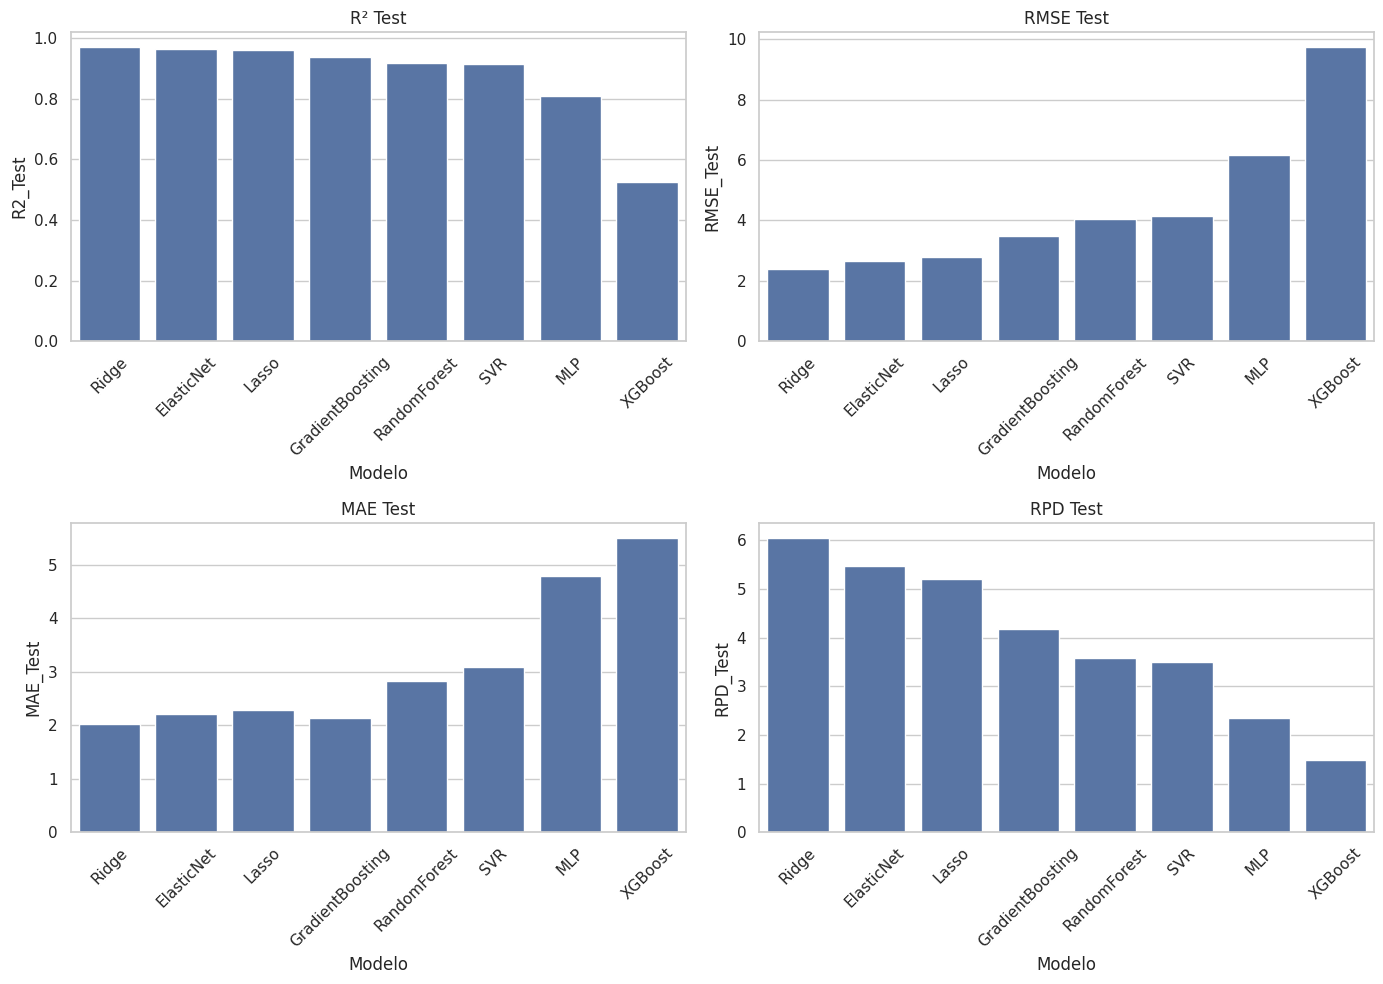

In [ ]:
# =========================================================
# BARRAS DE MÉTRICAS TEST
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=results_df, x="Modelo", y="R2_Test", ax=axes[0,0])
axes[0,0].set_title("R² Test")
axes[0,0].tick_params(axis='x', rotation=45)

sns.barplot(data=results_df, x="Modelo", y="RMSE_Test", ax=axes[0,1])
axes[0,1].set_title("RMSE Test")
axes[0,1].tick_params(axis='x', rotation=45)

sns.barplot(data=results_df, x="Modelo", y="MAE_Test", ax=axes[1,0])
axes[1,0].set_title("MAE Test")
axes[1,0].tick_params(axis='x', rotation=45)

sns.barplot(data=results_df, x="Modelo", y="RPD_Test", ax=axes[1,1])
axes[1,1].set_title("RPD Test")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "02_test_barplots.png"), dpi=600)
plt.show()

In [ ]:
# =========================================================
# VALIDACIÓN CRUZADA BASE
# =========================================================
kf = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for model_name, model in models.items():
    fold = 1
    for tr_idx, va_idx in kf.split(X_train):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)

        r2, rmse, mae, bias, rpd = regression_metrics(y_va, y_pred)

        cv_rows.append({
            "Modelo": model_name,
            "Fold": fold,
            "R2": r2,
            "RMSE": rmse,
            "MAE": mae,
            "Bias": bias,
            "RPD": rpd
        })
        fold += 1

cv_results_df = pd.DataFrame(cv_rows)
print(cv_results_df.head())
save_df(cv_results_df, "03_cv_base_folds.xlsx")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.533e+00, tolerance: 1.366e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.124e+00, tolerance: 1.202e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.161e+00, tolerance: 1.318e

  Modelo  Fold        R2      RMSE       MAE      Bias       RPD
0    SVR     1  0.975853  1.798702  1.448216  0.312544  6.646333
1    SVR     2  0.967289  2.710574  1.919806 -0.309312  5.710407
2    SVR     3  0.986190  1.526556  1.229608 -0.117367  8.788680
3    SVR     4  0.983679  1.862338  1.413983  0.949944  8.084166
4    SVR     5  0.963358  2.861331  1.643320 -1.201832  5.395408
Guardado: results_sg15/03_cv_base_folds.xlsx


In [ ]:
# =========================================================
# RESUMEN CV
# =========================================================
summary_rows = []

for model_name, group in cv_results_df.groupby("Modelo"):
    n = len(group)
    for metric in ["R2", "RMSE", "MAE", "Bias", "RPD"]:
        vals = group[metric].values.astype(float)
        mean = np.mean(vals)
        std = np.std(vals, ddof=1)
        low, high = ci95(mean, std, n)
        summary_rows.append({
            "Modelo": model_name,
            "Métrica": metric,
            "Media": round(mean, 4),
            "Std": round(std, 4),
            "IC95_inf": round(low, 4),
            "IC95_sup": round(high, 4),
            "Media±Std": f"{mean:.4f} ± {std:.4f}"
        })

cv_summary_df = pd.DataFrame(summary_rows)
print(cv_summary_df.head(10))
save_df(cv_summary_df, "04_cv_base_summary.xlsx")

             Modelo Métrica   Media     Std  IC95_inf  IC95_sup  \
0        ElasticNet      R2  0.9839  0.0095    0.9756    0.9922   
1        ElasticNet    RMSE  1.6882  0.5925    1.1689    2.2076   
2        ElasticNet     MAE  1.3138  0.4658    0.9055    1.7220   
3        ElasticNet    Bias  0.0971  0.6013   -0.4299    0.6241   
4        ElasticNet     RPD  9.2495  3.4076    6.2626   12.2364   
5  GradientBoosting      R2  0.9682  0.0185    0.9519    0.9844   
6  GradientBoosting    RMSE  2.2954  0.6642    1.7132    2.8776   
7  GradientBoosting     MAE  0.9634  0.2414    0.7518    1.1751   
8  GradientBoosting    Bias  0.0190  0.6184   -0.5230    0.5611   
9  GradientBoosting     RPD  7.0019  3.4533    3.9750   10.0288   

         Media±Std  
0  0.9839 ± 0.0095  
1  1.6882 ± 0.5925  
2  1.3138 ± 0.4658  
3  0.0971 ± 0.6013  
4  9.2495 ± 3.4076  
5  0.9682 ± 0.0185  
6  2.2954 ± 0.6642  
7  0.9634 ± 0.2414  
8  0.0190 ± 0.6184  
9  7.0019 ± 3.4533  
Guardado: results_sg15/04_cv_ba

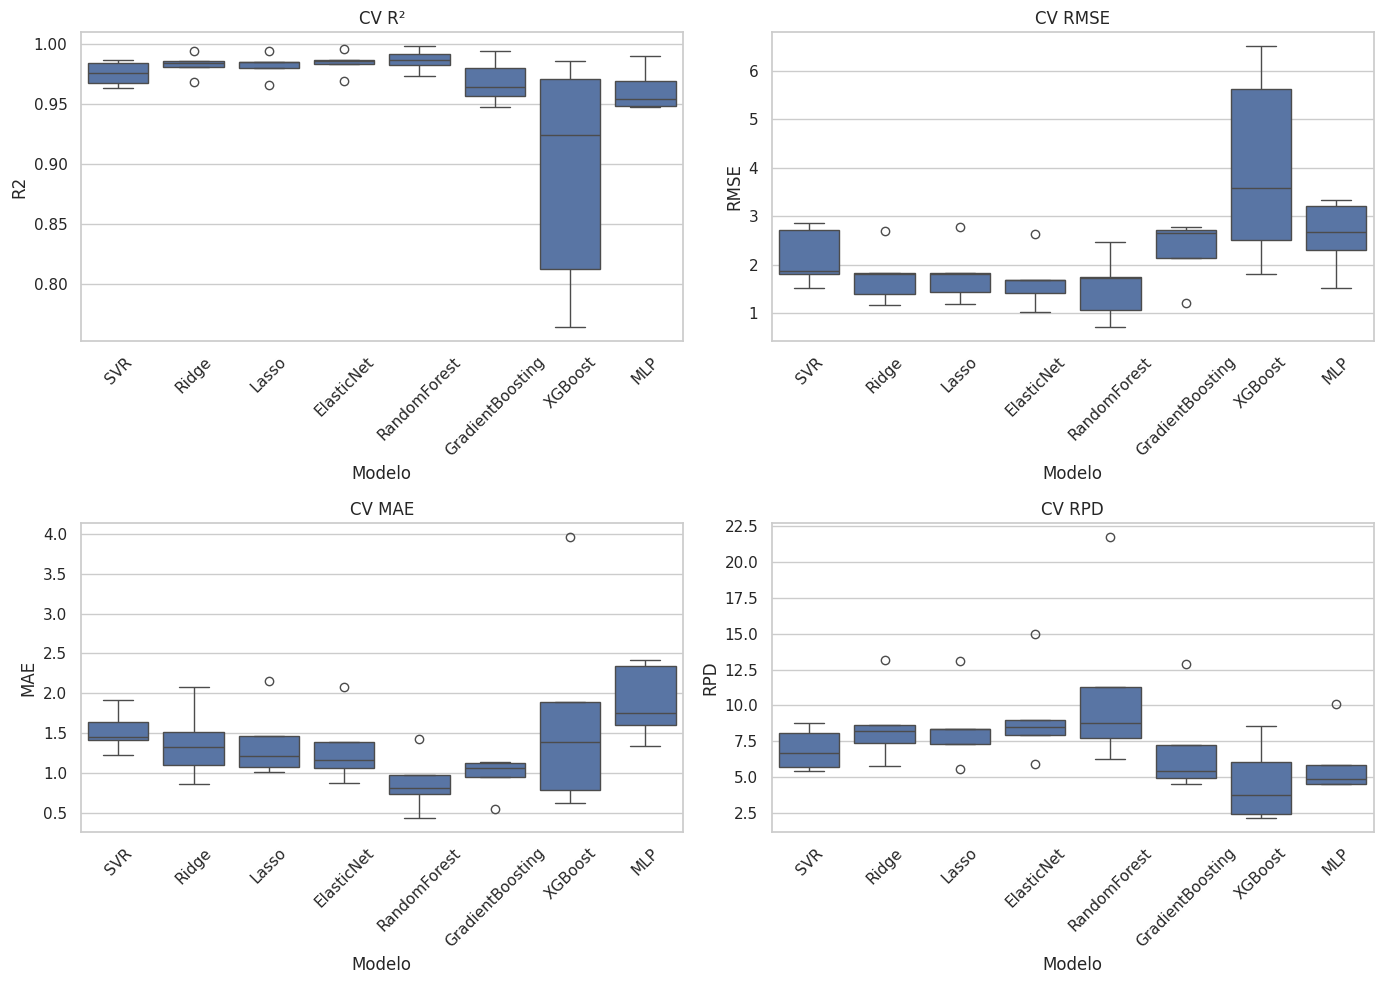

In [ ]:
# =========================================================
# BOXPLOTS CV
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=cv_results_df, x="Modelo", y="R2", ax=axes[0,0])
axes[0,0].set_title("CV R²")
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=cv_results_df, x="Modelo", y="RMSE", ax=axes[0,1])
axes[0,1].set_title("CV RMSE")
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=cv_results_df, x="Modelo", y="MAE", ax=axes[1,0])
axes[1,0].set_title("CV MAE")
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=cv_results_df, x="Modelo", y="RPD", ax=axes[1,1])
axes[1,1].set_title("CV RPD")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "05_cv_boxplots.png"), dpi=600)
plt.show()

In [ ]:
# =========================================================
# SELECCIÓN ROBUSTA DEL MEJOR MODELO
# =========================================================
cv_pivot = cv_summary_df.pivot(index="Modelo", columns="Métrica", values="Media").reset_index()

selection_df = results_df.merge(
    cv_pivot[["Modelo", "R2", "RMSE", "MAE", "RPD"]],
    on="Modelo",
    suffixes=("_TestMetrics", "_CV")
)

selection_df["rank_R2_test"] = selection_df["R2_Test"].rank(ascending=False, method="min")
selection_df["rank_RMSE_test"] = selection_df["RMSE_Test"].rank(ascending=True, method="min")
selection_df["rank_R2_cv"] = selection_df["R2"].rank(ascending=False, method="min")
selection_df["rank_RMSE_cv"] = selection_df["RMSE"].rank(ascending=True, method="min")

selection_df["Global_rank_score"] = (
    selection_df["rank_R2_test"] +
    selection_df["rank_RMSE_test"] +
    selection_df["rank_R2_cv"] +
    selection_df["rank_RMSE_cv"]
)

selection_df = selection_df.sort_values(by="Global_rank_score").reset_index(drop=True)

print(selection_df[[
    "Modelo", "R2_Test", "RMSE_Test", "R2", "RMSE", "Global_rank_score"
]])

save_df(selection_df, "06_model_selection_ranking.xlsx")

BEST_MODEL_NAME = selection_df.loc[0, "Modelo"]
print("Mejor modelo seleccionado:", BEST_MODEL_NAME)

             Modelo  R2_Test  RMSE_Test      R2    RMSE  Global_rank_score
0             Ridge   0.9712     2.3993  0.9824  1.7797                8.0
1        ElasticNet   0.9648     2.6544  0.9839  1.6882                8.0
2      RandomForest   0.9174     4.0636  0.9861  1.5362               12.0
3             Lasso   0.9611     2.7892  0.9818  1.8054               14.0
4  GradientBoosting   0.9396     3.4752  0.9682  2.2954               20.0
5               SVR   0.9141     4.1449  0.9753  2.1519               22.0
6               MLP   0.8104     6.1581  0.9614  2.6057               28.0
7           XGBoost   0.5250     9.7468  0.8911  4.0033               32.0
Guardado: results_sg15/06_model_selection_ranking.xlsx
Mejor modelo seleccionado: Ridge


In [ ]:
# =========================================================
# GRID SEARCH DEL MEJOR MODELO
# =========================================================
def build_base_pipeline_for_model(model_name):
    if model_name == "MLP":
        model = MLPRegressor(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    elif model_name == "Ridge":
        model = Ridge()
    else:
        raise ValueError(f"No hay grid predefinido para {model_name}. Ajusta manualmente.")

    steps = PREPROCESSING_STEPS.copy()
    steps.append(("model", model))
    return Pipeline(steps)

def get_param_grid(model_name):
    if model_name == "MLP":
        return {
            "model__hidden_layer_sizes": [(50,), (100,), (100,50), (120,60), (150,75)],
            "model__activation": ["relu", "tanh"],
            "model__solver": ["adam", "lbfgs"],
            "model__alpha": [0.0001, 0.001, 0.01, 0.1],
            "model__learning_rate_init": [0.001, 0.01]
        }
    elif model_name == "Ridge":
        return {
            "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000],
            "model__fit_intercept": [True, False],
            "model__solver": ["auto", "svd", "cholesky", "lsqr", "sag"]
        }
    else:
        raise ValueError(f"No hay param_grid definido para {model_name}.")

if BEST_MODEL_NAME in ["MLP", "Ridge"]:
    best_pipeline = build_base_pipeline_for_model(BEST_MODEL_NAME)
    param_grid = get_param_grid(BEST_MODEL_NAME)

    grid = GridSearchCV(
        estimator=best_pipeline,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=N_JOBS,
        verbose=2,
        refit=True,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    print("Best params:", grid.best_params_)
    print("Best CV RMSE:", -grid.best_score_)

    grid_results_df = pd.DataFrame(grid.cv_results_)
    save_df(grid_results_df, "07_gridsearch_results.xlsx")

    best_model_optimized = grid.best_estimator_

    pred_train = best_model_optimized.predict(X_train)
    pred_test = best_model_optimized.predict(X_test)

    r2_tr, rmse_tr, mae_tr, bias_tr, rpd_tr = regression_metrics(y_train, pred_train)
    r2_te, rmse_te, mae_te, bias_te, rpd_te = regression_metrics(y_test, pred_test)

    optimized_metrics_df = pd.DataFrame([{
        "Modelo": f"{BEST_MODEL_NAME}_optimized",
        "R2_Train": r2_tr,
        "RMSE_Train": rmse_tr,
        "MAE_Train": mae_tr,
        "Bias_Train": bias_tr,
        "RPD_Train": rpd_tr,
        "R2_Test": r2_te,
        "RMSE_Test": rmse_te,
        "MAE_Test": mae_te,
        "Bias_Test": bias_te,
        "RPD_Test": rpd_te
    }]).round(4)

    print(optimized_metrics_df)
    save_df(optimized_metrics_df, "08_best_model_optimized_metrics.xlsx")
else:
    print("El mejor modelo no tiene grid predefinido en este script. Continúa con el modelo base o define su grid.")
    best_model_optimized = fitted_models[BEST_MODEL_NAME]

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best params: {'model__alpha': 10, 'model__fit_intercept': True, 'model__solver': 'lsqr'}
Best CV RMSE: 1.6601649273309547
Guardado: results_sg15/07_gridsearch_results.xlsx
            Modelo  R2_Train  RMSE_Train  MAE_Train  Bias_Train  RPD_Train  \
0  Ridge_optimized    0.9909      1.3502     1.0162         0.0    10.5403   

   R2_Test  RMSE_Test  MAE_Test  Bias_Test  RPD_Test  
0   0.9659      2.612    2.1886    -0.1005     5.555  
Guardado: results_sg15/08_best_model_optimized_metrics.xlsx


In [ ]:
# =========================================================
# LOBO POR BLOQUES
# =========================================================
def build_pipeline_for_lobo():
    if BEST_MODEL_NAME == "MLP" and 'grid' in globals() and BEST_MODEL_NAME in ["MLP", "Ridge"]:
        return grid.best_estimator_
    else:
        return fitted_models[BEST_MODEL_NAME]

Xtr = ensure_numpy(X_train)
Xte = ensure_numpy(X_test)
ytr = ensure_numpy(y_train)
yte = ensure_numpy(y_test)

n_bands = Xtr.shape[1]
block_size = 10

blocks = []
for start in range(0, n_bands, block_size):
    end = min(start + block_size, n_bands)
    blocks.append((start, end))

# baseline
baseline_model = build_pipeline_for_lobo()
baseline_model.fit(Xtr, ytr)
baseline_pred = baseline_model.predict(Xte)
base_r2, base_rmse, base_mae, base_bias, base_rpd = regression_metrics(yte, baseline_pred)

baseline_df = pd.DataFrame([{
    "Modelo": f"{BEST_MODEL_NAME}_baseline",
    "R2": base_r2,
    "RMSE": base_rmse,
    "MAE": base_mae,
    "Bias": base_bias,
    "RPD": base_rpd,
    "Bandas": n_bands
}]).round(4)

print(baseline_df)
save_df(baseline_df, "09_lobo_baseline.xlsx")

lobo_rows = []

for i, (start, end) in enumerate(blocks, start=1):
    keep_idx = np.r_[0:start, end:n_bands]

    Xtr_red = Xtr[:, keep_idx]
    Xte_red = Xte[:, keep_idx]

    model = build_pipeline_for_lobo()

    t0 = time.perf_counter()
    model.fit(Xtr_red, ytr)
    train_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    pred = model.predict(Xte_red)
    infer_total = time.perf_counter() - t1
    infer_per_sample = infer_total / len(Xte_red)

    r2, rmse, mae, bias, rpd = regression_metrics(yte, pred)

    lobo_rows.append({
        "Block_ID": i,
        "Band_start_idx": start,
        "Band_end_idx": end - 1,
        "WL_start": wavelengths[start] if len(wavelengths) > start else start,
        "WL_end": wavelengths[end - 1] if len(wavelengths) > (end - 1) else end - 1,
        "Bands_removed": end - start,
        "Bands_kept": len(keep_idx),
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "RPD": rpd,
        "Delta_R2": r2 - base_r2,
        "Delta_RMSE": rmse - base_rmse,
        "Delta_MAE": mae - base_mae,
        "Train_time_s": train_time,
        "Inference_total_s": infer_total,
        "Inference_per_sample_s": infer_per_sample
    })

lobo_df = pd.DataFrame(lobo_rows).round(6)
save_df(lobo_df, "10_lobo_block_results.xlsx")

lobo_importance_df = lobo_df.sort_values(by="Delta_RMSE", ascending=False).reset_index(drop=True)
lobo_reduction_df = lobo_df.sort_values(by="Delta_RMSE", ascending=True).reset_index(drop=True)

save_df(lobo_importance_df, "11_lobo_importance_rank.xlsx")
save_df(lobo_reduction_df, "12_lobo_reduction_rank.xlsx")

print(lobo_importance_df.head(10))
print(lobo_reduction_df.head(10))

           Modelo      R2    RMSE     MAE    Bias     RPD  Bandas
0  Ridge_baseline  0.9712  2.3993  2.0245  0.0934  6.0474     300
Guardado: results_sg15/09_lobo_baseline.xlsx
Guardado: results_sg15/10_lobo_block_results.xlsx
Guardado: results_sg15/11_lobo_importance_rank.xlsx
Guardado: results_sg15/12_lobo_reduction_rank.xlsx
   Block_ID  Band_start_idx  Band_end_idx  WL_start   WL_end  Bands_removed  \
0         1               0             9    390.19   408.59             10   
1        29             280           289    993.71  1014.18             10   
2        18             170           179    748.96   768.62             10   
3        19             180           189    770.81   790.54             10   
4        26             250           259    925.98   946.22             10   
5        25             240           249    903.57   923.74             10   
6        27             260           269    948.48   968.80             10   
7        28             270           

In [ ]:
# =========================================================
# REDUCCIÓN ESPECTRAL AUTOMÁTICA
# =========================================================
least_important_blocks = lobo_reduction_df.head(5)["Block_ID"].tolist()
print("Bloques menos importantes:", least_important_blocks)

block_map = {row["Block_ID"]: (int(row["Band_start_idx"]), int(row["Band_end_idx"]) + 1)
             for _, row in lobo_df.iterrows()}

def block_ids_to_band_indices(block_ids):
    idx = []
    for bid in block_ids:
        start, end = block_map[bid]
        idx.extend(list(range(start, end)))
    return sorted(idx)

remove_A = block_ids_to_band_indices(least_important_blocks[:4])
remove_B = block_ids_to_band_indices(least_important_blocks[:5])

print("Bandas a remover A:", remove_A[:20], "... total:", len(remove_A))
print("Bandas a remover B:", remove_B[:20], "... total:", len(remove_B))

Bloques menos importantes: [22, 16, 15, 23, 24]
Bandas a remover A: [140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159] ... total: 40
Bandas a remover B: [140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159] ... total: 50


In [ ]:
# =========================================================
# COMPARACIÓN FULL VS REDUCED
# =========================================================
def evaluate_model(Xtr, Xte, ytr, yte, bands_remove, model_name):
    keep_idx = [i for i in range(Xtr.shape[1]) if i not in bands_remove]

    Xtr_red = Xtr[:, keep_idx]
    Xte_red = Xte[:, keep_idx]

    if BEST_MODEL_NAME in ["MLP", "Ridge"] and 'grid' in globals():
        model = build_base_pipeline_for_model(BEST_MODEL_NAME)
        model.set_params(**grid.best_params_)
    else:
        model = fitted_models[BEST_MODEL_NAME]

    t0 = time.perf_counter()
    model.fit(Xtr_red, ytr)
    train_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    pred = model.predict(Xte_red)
    infer_total = time.perf_counter() - t1
    infer_per_sample = infer_total / len(Xte_red)

    r2, rmse, mae, bias, rpd = regression_metrics(yte, pred)

    return {
        "Modelo": model_name,
        "Bandas": len(keep_idx),
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "RPD": rpd,
        "Train_time_s": train_time,
        "Inference_total_s": infer_total,
        "Inference_per_sample_s": infer_per_sample
    }, pred, keep_idx

full_results, pred_full, keep_full = evaluate_model(Xtr, Xte, ytr, yte, [], "full")
A_results, pred_A, keep_A = evaluate_model(Xtr, Xte, ytr, yte, remove_A, "reduced_A")
B_results, pred_B, keep_B = evaluate_model(Xtr, Xte, ytr, yte, remove_B, "reduced_B")

comparison_df = pd.DataFrame([full_results, A_results, B_results]).round(4)

base_r2 = comparison_df.loc[comparison_df["Modelo"] == "full", "R2"].values[0]
base_rmse = comparison_df.loc[comparison_df["Modelo"] == "full", "RMSE"].values[0]
base_mae = comparison_df.loc[comparison_df["Modelo"] == "full", "MAE"].values[0]

comparison_df["Delta_R2_vs_full"] = (comparison_df["R2"] - base_r2).round(4)
comparison_df["Delta_RMSE_vs_full"] = (comparison_df["RMSE"] - base_rmse).round(4)
comparison_df["Delta_MAE_vs_full"] = (comparison_df["MAE"] - base_mae).round(4)

print(comparison_df)
save_df(comparison_df, "13_full_vs_reduced_comparison.xlsx")

      Modelo  Bandas      R2    RMSE     MAE    Bias     RPD  Train_time_s  \
0       full     300  0.9659  2.6120  2.1886 -0.1005  5.5550        0.0087   
1  reduced_A     260  0.9665  2.5877  2.1197 -0.2547  5.6070        0.0067   
2  reduced_B     250  0.9666  2.5843  2.1097 -0.2796  5.6145        0.0059   

   Inference_total_s  Inference_per_sample_s  Delta_R2_vs_full  \
0             0.0018                  0.0001            0.0000   
1             0.0024                  0.0001            0.0006   
2             0.0015                  0.0001            0.0007   

   Delta_RMSE_vs_full  Delta_MAE_vs_full  
0              0.0000             0.0000  
1             -0.0243            -0.0689  
2             -0.0277            -0.0789  
Guardado: results_sg15/13_full_vs_reduced_comparison.xlsx


In [ ]:
# =========================================================
# ELEGIR MODELO FINAL REDUCIDO
# =========================================================
# criterio simple: mayor R2 y menor RMSE entre los reducidos
reduced_only = comparison_df[comparison_df["Modelo"] != "full"].copy()
reduced_only = reduced_only.sort_values(by=["R2", "RMSE"], ascending=[False, True]).reset_index(drop=True)

FINAL_MODEL_VARIANT = reduced_only.loc[0, "Modelo"]
print("Modelo final reducido elegido:", FINAL_MODEL_VARIANT)

if FINAL_MODEL_VARIANT == "reduced_A":
    FINAL_REMOVE = remove_A
elif FINAL_MODEL_VARIANT == "reduced_B":
    FINAL_REMOVE = remove_B
else:
    FINAL_REMOVE = []

print("Número de bandas finales:", Xtr.shape[1] - len(FINAL_REMOVE))

Modelo final reducido elegido: reduced_B
Número de bandas finales: 250


In [ ]:
# =========================================================
# CV DEL MODELO FINAL REDUCIDO
# =========================================================
keep_final = [i for i in range(Xtr.shape[1]) if i not in FINAL_REMOVE]
Xtr_final = Xtr[:, keep_final]

rkf = RepeatedKFold(n_splits=CV_SPLITS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)

cv_final_rows = []

fold_id = 1
for tr_idx, va_idx in rkf.split(Xtr_final):
    X_fold_tr, X_fold_va = Xtr_final[tr_idx], Xtr_final[va_idx]
    y_fold_tr, y_fold_va = ytr[tr_idx], ytr[va_idx]

    if BEST_MODEL_NAME in ["MLP", "Ridge"] and 'grid' in globals():
        model = build_base_pipeline_for_model(BEST_MODEL_NAME)
        model.set_params(**grid.best_params_)
    else:
        model = fitted_models[BEST_MODEL_NAME]

    model.fit(X_fold_tr, y_fold_tr)
    y_pred = model.predict(X_fold_va)

    r2, rmse, mae, bias, rpd = regression_metrics(y_fold_va, y_pred)

    cv_final_rows.append({
        "Fold": fold_id,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "RPD": rpd
    })
    fold_id += 1

cv_final_df = pd.DataFrame(cv_final_rows)
print(cv_final_df.head())
save_df(cv_final_df, "14_cv_final_model_folds.xlsx")

cv_final_summary_df = summarize_cv(cv_final_df)
print(cv_final_summary_df)
save_df(cv_final_summary_df, "15_cv_final_model_summary.xlsx")

   Fold        R2      RMSE       MAE      Bias        RPD
0     1  0.983268  1.497256  1.131712 -0.424570   7.984457
1     2  0.965755  2.773386  2.131408  0.326812   5.581076
2     3  0.980511  1.813496  1.404831 -0.445088   7.398090
3     4  0.985520  1.754109  1.534297  1.074935   8.582965
4     5  0.996287  0.910885  0.694063 -0.012039  16.948410
Guardado: results_sg15/14_cv_final_model_folds.xlsx
  Métrica   Media     Std  IC95_inf  IC95_sup        Media±Std
0      R2  0.9818  0.0092    0.9782    0.9854  0.9818 ± 0.0092
1    RMSE  1.8044  0.4942    1.6107    1.9981  1.8044 ± 0.4942
2     MAE  1.3936  0.3536    1.2550    1.5322  1.3936 ± 0.3536
3    Bias  0.0653  0.5675   -0.1571    0.2878  0.0653 ± 0.5675
4     RPD  8.4793  2.5457    7.4814    9.4772  8.4793 ± 2.5457
Guardado: results_sg15/15_cv_final_model_summary.xlsx


In [ ]:
# =========================================================
# TEST EXTERNO FINAL
# =========================================================
Xte_final = Xte[:, keep_final]

if BEST_MODEL_NAME in ["MLP", "Ridge"] and 'grid' in globals():
    model_final = build_base_pipeline_for_model(BEST_MODEL_NAME)
    model_final.set_params(**grid.best_params_)
else:
    model_final = fitted_models[BEST_MODEL_NAME]

model_final.fit(Xtr_final, ytr)
y_pred_test_final = model_final.predict(Xte_final)

r2_test, rmse_test, mae_test, bias_test, rpd_test = regression_metrics(yte, y_pred_test_final)

external_test_df = pd.DataFrame([{
    "Dataset": "External test",
    "Modelo": FINAL_MODEL_VARIANT,
    "Bandas": len(keep_final),
    "R2": r2_test,
    "RMSE": rmse_test,
    "MAE": mae_test,
    "Bias": bias_test,
    "RPD": rpd_test,
    "n_samples": len(yte)
}]).round(4)

print(external_test_df)
save_df(external_test_df, "16_external_test_final_model.xlsx")

         Dataset     Modelo  Bandas      R2    RMSE     MAE    Bias     RPD  \
0  External test  reduced_B     250  0.9666  2.5843  2.1097 -0.2796  5.6145   

   n_samples  
0         20  
Guardado: results_sg15/16_external_test_final_model.xlsx


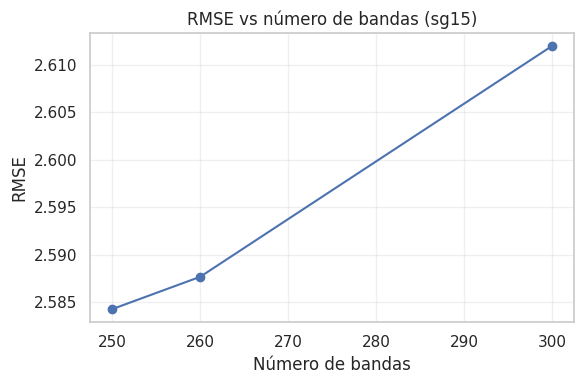

In [ ]:
# =========================================================
# RMSE VS NÚMERO DE BANDAS
# =========================================================
plt.figure(figsize=(6,4))
plt.plot(comparison_df["Bandas"], comparison_df["RMSE"], marker="o")
plt.xlabel("Número de bandas")
plt.ylabel("RMSE")
plt.title(f"RMSE vs número de bandas ({ANALYSIS_MODE})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "17_rmse_vs_bands.png"), dpi=600)
plt.show()

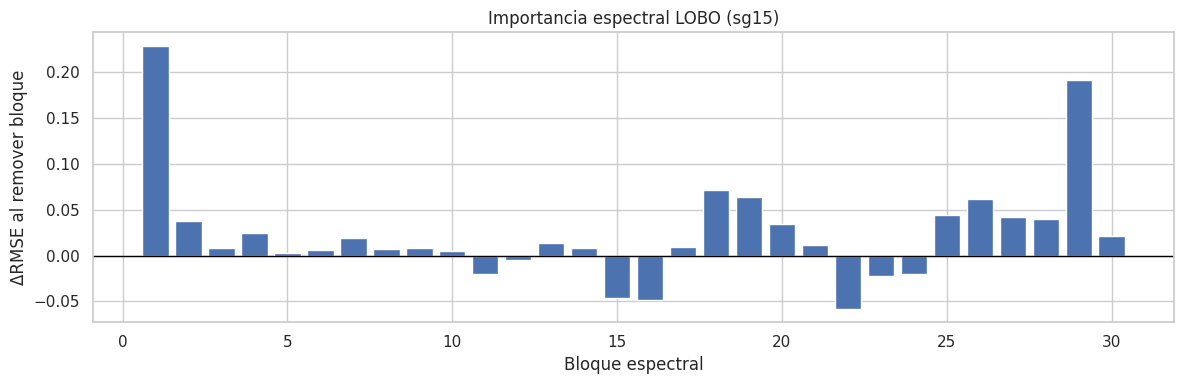

In [ ]:
# =========================================================
# IMPORTANCIA LOBO
# =========================================================
plt.figure(figsize=(12,4))
plt.bar(lobo_df["Block_ID"], lobo_df["Delta_RMSE"])
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Bloque espectral")
plt.ylabel("ΔRMSE al remover bloque")
plt.title(f"Importancia espectral LOBO ({ANALYSIS_MODE})")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "18_lobo_importance.png"), dpi=600)
plt.show()

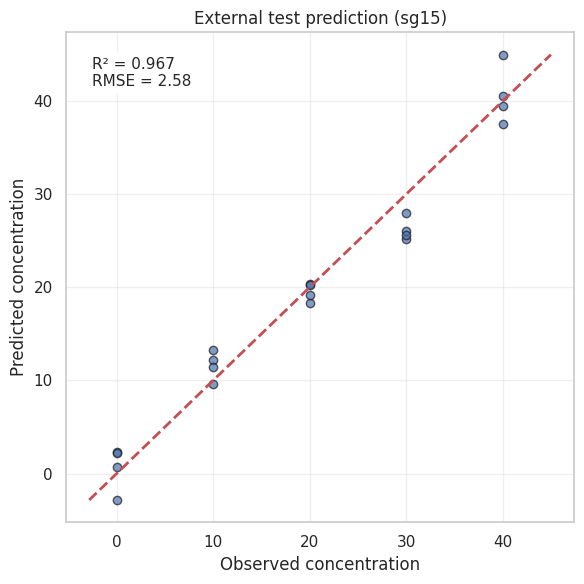

In [ ]:
# =========================================================
# PREDICHO VS OBSERVADO
# =========================================================
plt.figure(figsize=(6,6))
plt.scatter(yte, y_pred_test_final, alpha=0.7, edgecolor="k")

minv = min(yte.min(), y_pred_test_final.min())
maxv = max(yte.max(), y_pred_test_final.max())

plt.plot([minv, maxv], [minv, maxv], "r--", linewidth=2)

textstr = "\n".join((
    f"R² = {r2_test:.3f}",
    f"RMSE = {rmse_test:.2f}"
))

plt.text(
    0.05, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white")
)

plt.xlabel("Observed concentration")
plt.ylabel("Predicted concentration")
plt.title(f"External test prediction ({ANALYSIS_MODE})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "19_predicted_vs_observed_final.png"), dpi=600)
plt.show()

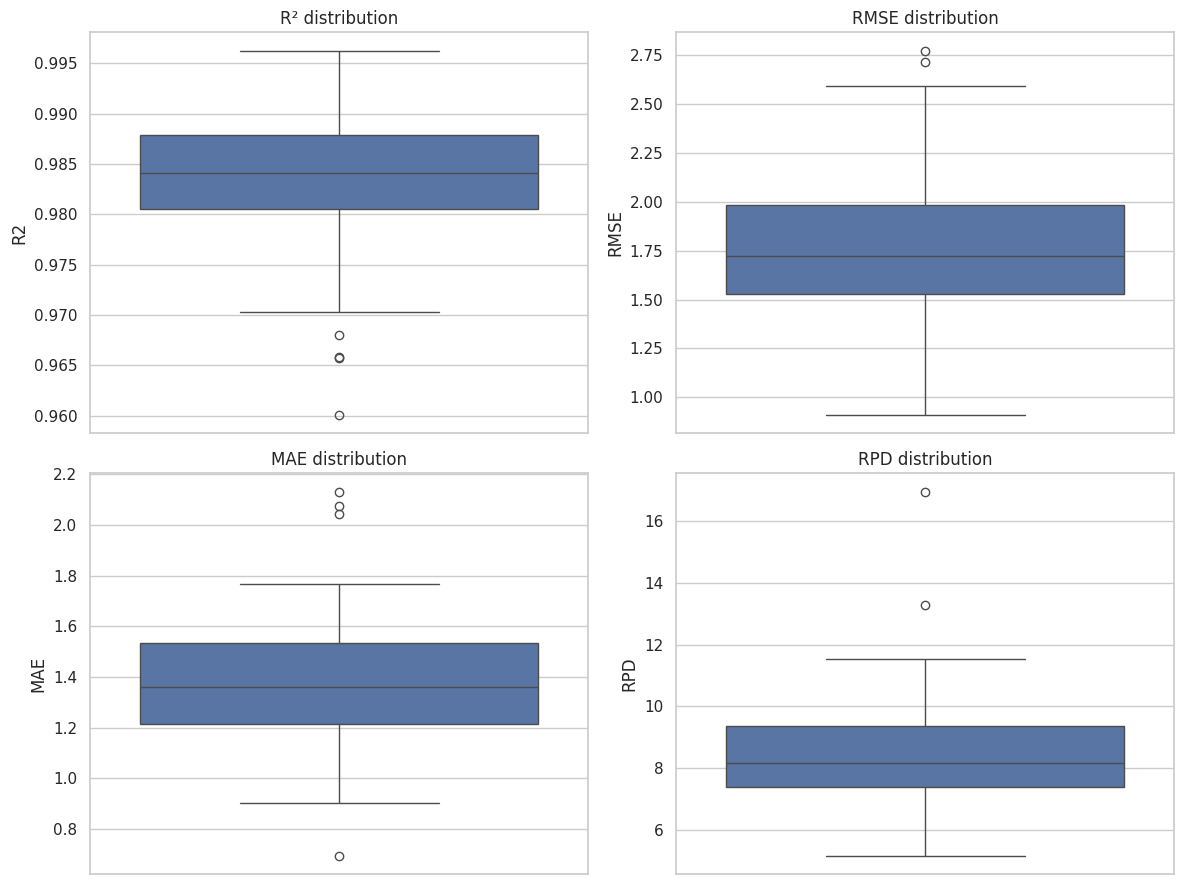

In [ ]:
# =========================================================
# BOXPLOTS DEL MODELO FINAL
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(data=cv_final_df, y="R2", ax=axes[0,0])
axes[0,0].set_title("R² distribution")

sns.boxplot(data=cv_final_df, y="RMSE", ax=axes[0,1])
axes[0,1].set_title("RMSE distribution")

sns.boxplot(data=cv_final_df, y="MAE", ax=axes[1,0])
axes[1,0].set_title("MAE distribution")

sns.boxplot(data=cv_final_df, y="RPD", ax=axes[1,1])
axes[1,1].set_title("RPD distribution")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "20_cv_final_boxplots.png"), dpi=600)
plt.show()

In [ ]:
import time
import numpy as np

# ==========================
# TIEMPO DE INFERENCIA
# ==========================

def measure_inference_time(model, X_test, n_runs=100):

    # warm up
    model.predict(X_test[:5])

    start = time.perf_counter()

    for _ in range(n_runs):
        preds = model.predict(X_test)

    end = time.perf_counter()

    total_time = (end - start) / n_runs
    per_sample = total_time / len(X_test)

    return total_time, per_sample


import time
import numpy as np

def measure_inference_time_reduced(model, X_test, keep_idx=None, n_runs=100):
    """
    Mide tiempo de inferencia.
    Si keep_idx se proporciona, primero reduce X_test a esas bandas.
    """
    X_eval = X_test[:, keep_idx] if keep_idx is not None else X_test
    X_eval = np.asarray(X_eval, dtype=float)

    # warm-up
    _ = model.predict(X_eval[:5])

    start = time.perf_counter()
    for _ in range(n_runs):
        _ = model.predict(X_eval)
    end = time.perf_counter()

    total_time = (end - start) / n_runs
    per_sample = total_time / len(X_eval)

    return total_time, per_sample

total_time, per_sample = measure_inference_time_reduced(
    model=model_final,
    X_test=X_test,
    keep_idx=keep_final,
    n_runs=100
)

print("Inference total:", total_time)
print("Inference per sample:", per_sample)

Inference total: 0.001191836279999734
Inference per sample: 5.9591813999986704e-05
